# Data Loading

In [1]:
# import libraries

import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.proportion import proportions_ztest
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
from datetime import datetime

# load the cleaned dataset

df = pd.read_csv("clean_credit_applications.csv")
df.columns

Index(['_id', 'processing_timestamp', 'applicant_info.full_name',
       'applicant_info.email', 'applicant_info.ssn',
       'applicant_info.ip_address', 'applicant_info.gender',
       'applicant_info.date_of_birth', 'applicant_info.zip_code',
       'financials.annual_income', 'financials.credit_history_months',
       'financials.debt_to_income', 'financials.savings_balance',
       'decision.loan_approved', 'decision.rejection_reason', 'loan_purpose',
       'decision.interest_rate', 'decision.approved_amount',
       'spending_Adult Entertainment', 'spending_Alcohol', 'spending_Dining',
       'spending_Education', 'spending_Entertainment', 'spending_Fitness',
       'spending_Gambling', 'spending_Groceries', 'spending_Healthcare',
       'spending_Insurance', 'spending_Rent', 'spending_Shopping',
       'spending_Transportation', 'spending_Travel', 'spending_Utilities'],
      dtype='object')

# Bias Detection

This section investigates whether the loan approval process exhibits systematic disparities across protected attributes. Using statistical tests and fairness metrics, we assess whether approval outcomes differ significantly by gender and age. The objective is to identify potential bias patterns and evaluate fairness risks within the decision-making process.

## Gender Disparate Impact

To evaluate gender-based fairness, we analyze approval rates across gender groups and compute the Disparate Impact (DI) ratio, following the four-fifths rule. Statistical testing and logistic regression are used to determine whether observed differences are significant and whether gender is a meaningful predictor of loan approval outcomes.

### Loan Approval Distribution by Gender

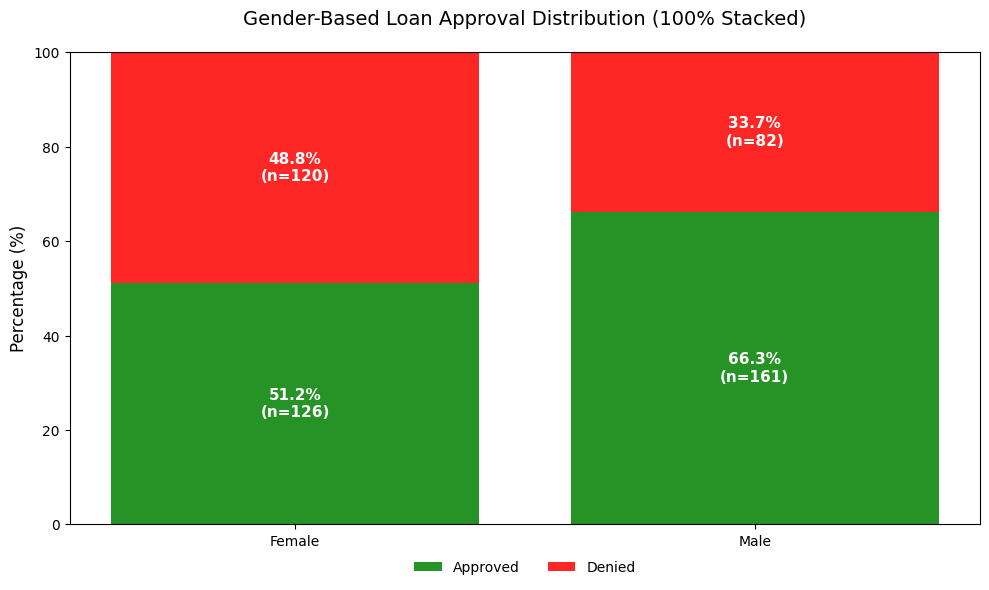

In [2]:
# create a summary variable that groups gender and approval to simplify code reading later on

gender_summary = df.groupby('applicant_info.gender')['decision.loan_approved'].agg(['mean','sum', 'count'])

# prepare the percentages and raw counts

labels = gender_summary.index
approved_pct = gender_summary['mean'] * 100
denied_pct = 100 - approved_pct
approved_cnt = gender_summary['sum']
denied_cnt = gender_summary['count'] - gender_summary['sum']

fig, ax = plt.subplots(figsize=(10, 6))

# create the 100% stacked bars

ax.bar(labels, approved_pct, label='Approved', color='green', alpha=0.85)
ax.bar(labels, denied_pct, bottom=approved_pct, label='Denied', color='red', alpha=0.85)

# add readable labels inside the bars (percentage and count)

for i in range(len(labels)):
    ax.text(
        i,
        approved_pct.iloc[i] / 2,
        f"{approved_pct.iloc[i]:.1f}%\n(n={int(approved_cnt.iloc[i])})",
        ha='center',
        va='center',
        color='white',
        fontweight='bold',
        fontsize=11
    )

    ax.text(
        i,
        approved_pct.iloc[i] + denied_pct.iloc[i] / 2,
        f"{denied_pct.iloc[i]:.1f}%\n(n={int(denied_cnt.iloc[i])})",
        ha='center',
        va='center',
        color='white',
        fontweight='bold',
        fontsize=11
    )

# final details

ax.set_ylabel('Percentage (%)', fontsize=12)
ax.set_title('Gender-Based Loan Approval Distribution (100% Stacked)', fontsize=14, pad=20)
ax.set_ylim(0, 100)
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=False)

plt.tight_layout()
plt.show()

**Insights**:

- The Male gender has a higher approval rate (65.9%) than the Female gender (50.6%), with a difference of 15.3 p.p..

- For the Female gender, the loan approval and denial cases are almost the same, while for the Male gender, there are more cases of loan approval than denial (a difference of 31.8 p.p.).

Overall, there are indications of gender bias in loan approval outcomes.

### Disparate Impact Ratio

**DI = Approval Rate of Unpriviliged Group / Approval Rate of Priviliged Group**


The four-fifth rule is used to evaluate whether a selection process leads to adverse impact against any specific group.

According to the EEOC, a selection rate for any group that is less than four-fifths (or 80%) of the rate for the group with the highest selection rate may indicate adverse impact.

In [3]:
# verify unpriviliged and priviliged group

privileged = gender_summary['mean'].idxmax()    # group with highest approval rate
unprivileged = gender_summary['mean'].idxmin()  # group with lowest approval rate

print("Privileged group:", privileged)
print("Unprivileged group:", unprivileged)

Privileged group: Male
Unprivileged group: Female


In [4]:
# calculate disparate impact ratio

approval_rate_male = gender_summary.loc['Male', 'mean']
approval_rate_female = gender_summary.loc['Female', 'mean']

di = approval_rate_female / approval_rate_male
print("Disparate Impact (Female vs Male):", round(di, 2))

Disparate Impact (Female vs Male): 0.77


**Insights**:

DI < 0.8, indicating potencial disparate impact of loan approval for the Female gender, according to the four-fifths rule.

### Proportions Z-Test

Hypothesis testing for gender approval difference:

- H0 = The probability of getting a loan approved is the same for both women and men.
- H1 = The probability of getting a loan approved is not the same for both women and men.

In [5]:
# Z-test

count = [gender_summary.loc['Female', 'sum'], gender_summary.loc['Male', 'sum']]
nobs = [gender_summary.loc['Female', 'count'], gender_summary.loc['Male', 'count']]

stat, pval = proportions_ztest(count, nobs, alternative="two-sided")
print("Z-test p-value for gender approval difference:", round(pval, 4))

Z-test p-value for gender approval difference: 0.0007


**Insights**:

p-value < significance level of 5%, therefore, the difference detected between the Male and Female gender is statistically significant.

## Age-based Discrimination Patterns

We examine whether loan approval outcomes vary across age groups and across continuous age values. Using visual analysis, chi-square testing, and logistic regression, we assess whether age is statistically associated with approval decisions and whether patterns suggest potential age-based disparity.

### Age-Based Approval Composition with Linear Trendline

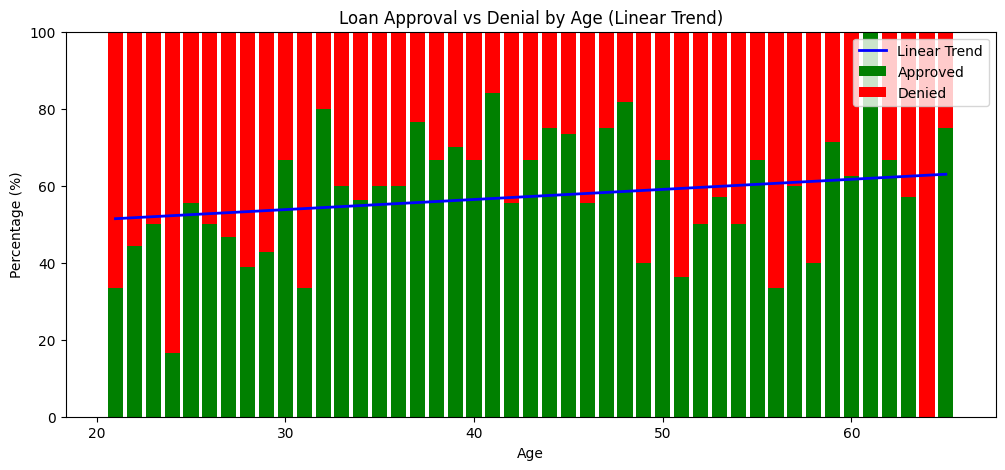

In [6]:
# create age 

df['dob'] = pd.to_datetime(df['applicant_info.date_of_birth'], errors='coerce')
today = pd.Timestamp("2024-01-01")

df['age'] = df['dob'].apply(lambda x: today.year - x.year - ((today.month, today.day) < (x.month, x.day)))


# create a age summary and make sure it is sorted

age_summary = df.groupby('age')['decision.loan_approved'].agg(['mean','sum', 'count'])
age_summary = age_summary.sort_index()

# create approval and denial rate in percentage

age_summary['approval_%'] = age_summary['mean'] * 100
age_summary['denial_%'] = 100 - age_summary['approval_%']

# create a linear regression for tendency

X = age_summary.index.values.reshape(-1,1)
Y = age_summary['approval_%'].values

model = LinearRegression()
model.fit(X, Y)

trend = model.predict(X)

# plot 100% stacked bar with linear trend 

plt.figure(figsize=(12,5))
plt.bar(age_summary.index, age_summary['approval_%'], label='Approved', color='green')
plt.bar(age_summary.index, age_summary['denial_%'], bottom=age_summary['approval_%'], label='Denied', color='red')

plt.plot(age_summary.index, trend, color='blue', linewidth=2, label='Linear Trend')

plt.xlabel('Age')
plt.ylabel('Percentage (%)')
plt.title('Loan Approval vs Denial by Age (Linear Trend)')
plt.legend()
plt.ylim(0,100)
plt.show()

**Insights**:

- The linear trend slopes upward, indicating that older applicants tend to have a slightly higher approval rate.

- Younger applicants, with ages from 20s to 30, have small approval rates, while middle-aged and old applicants, with ages from 30s to 60s, have high approval rates (bins analysis might enphasize this pattern).

Overall, there are indications of age-related disparities in loan approval outcomes.

### Logistic Regression

In [7]:
# create logit regression

X = df[['age']]   
y = df['decision.loan_approved']

X = sm.add_constant(X)  # add intercept


logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

# extract coefficient and p-value for age

coef_age = logit_model.params['age']
p_value_age = logit_model.pvalues['age']

# odds ratio

odds_ratio = np.exp(coef_age)

#  interpretation

if p_value_age < 0.05:
    significance = "statistically significant"
else:
    significance = "not statistically significant"

if odds_ratio > 1:
    direction = "increase"
elif odds_ratio < 1:
    direction = "decrease"
else:
    direction = "no change"

interpretation = (
    f"\nLogistic regression results for age predicting loan approval:\n"
    f"- Coefficient for age: {coef_age:.3f}\n"
    f"- Odds ratio: {odds_ratio:.3f}\n"
    f"- P-value: {p_value_age:.3f} → {significance}\n"
    f"\nInterpretation:\n"
)

if p_value_age < 0.05:
    interpretation += (
        f"Age is a statistically significant predictor of loan approval.\n"
        f"Each additional year of age is associated with a {direction} in the odds of approval "
        f"(odds multiplied by {odds_ratio:.3f} per year).\n"
        f"OR appears to have a small age-based effect, but, e.g. over 30 years the odds of approval will {direction} {odds_ratio**30:.3f}. \n"
        f"This suggests potential age-based disparity, though financial controls must be considered."
    )
else:
    interpretation += (
        f"Age is not a statistically significant predictor of loan approval.\n"
        f"There is no strong statistical evidence of age-based disparity at the 5% significance level."
    )

print(interpretation)

Optimization terminated successfully.
         Current function value: 0.669643
         Iterations 4
                             Logit Regression Results                             
Dep. Variable:     decision.loan_approved   No. Observations:                  489
Model:                              Logit   Df Residuals:                      487
Method:                               MLE   Df Model:                            1
Date:                    Thu, 05 Mar 2026   Pseudo R-squ.:                 0.01227
Time:                            20:22:01   Log-Likelihood:                -327.46
converged:                           True   LL-Null:                       -331.52
Covariance Type:                nonrobust   LLR p-value:                  0.004337
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.5891      0.345     -1.709      0.087      -1.265       0.0

### Aggregation Bias

In [8]:
# create meaningful age brackets since we realize a pattern between age groups and approval rates

bins = [18, 25, 40, 60, 100]
labels = ['Gen Z (18-25)', 'Millennials (26-40)', 'Gen X (41-60)', 'Seniors (60+)']
df['age_group'] = pd.cut(df['age'], bins=bins, labels=labels, right=False)

# create a contingency table (counts of approved vs denied per age group)

contingency_table = pd.crosstab(df['age_group'], df['decision.loan_approved'])

print(contingency_table)

decision.loan_approved  False  True 
age_group                           
Gen Z (18-25)              27     13
Millennials (26-40)       102    139
Gen X (41-60)              64    115
Seniors (60+)               9     20


#### Chi-Square test

Hypothesis testing for age-based discrimination:
- H0: Age group and loan approval are independent
- H1: Age group and loan approval are not independent

In [9]:
# Chi-Square test

chi2, pval, dof, expected = chi2_contingency(contingency_table)

print(f"Chi-Square Test p-value: {pval:.6f}")

Chi-Square Test p-value: 0.001851


**Insights**:

p-value < significance level of 5%, therefore, there is a statistically significant association between age group and loan approval.


#### Loan Approval Distribution by Age Group

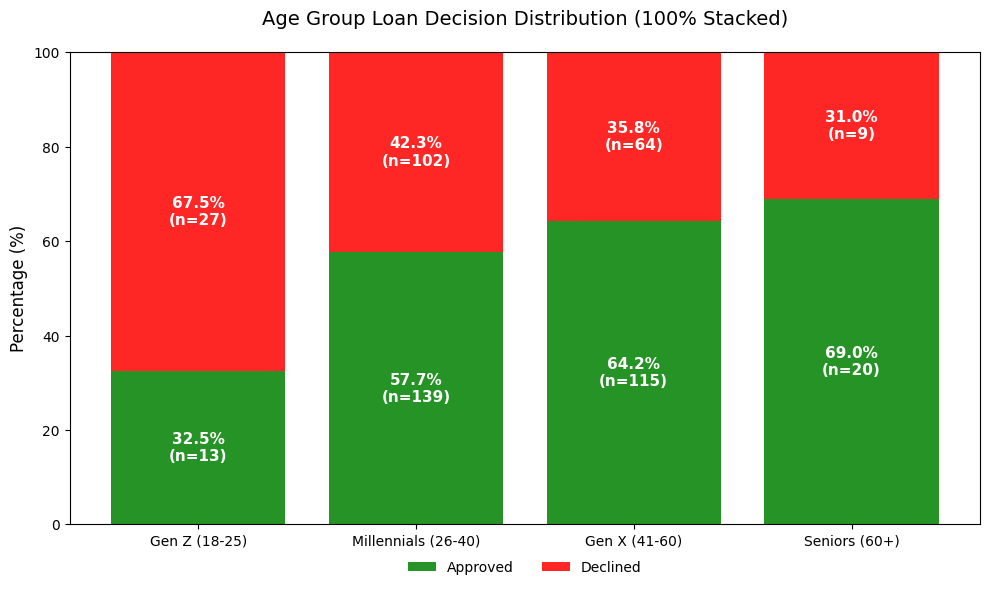

In [10]:
# compute percentage distribution per age group

contingency_table_percent = contingency_table.div(contingency_table.sum(axis=1), axis=0) * 100


# sort columns so approval comes first

contingency_table_percent = contingency_table_percent.sort_index(axis=1, ascending=False)

# rename for easier reading

contingency_table_percent = contingency_table_percent.rename(
    columns={True: "Approved", False: "Declined", "True": "Approved", "False": "Declined"}
)

contingency_table = contingency_table.rename(
    columns={True: "Approved", False: "Declined", "True": "Approved", "False": "Declined"}
)

# add label

labels = contingency_table_percent.index
approved_pct = contingency_table_percent["Approved"]
declined_pct = contingency_table_percent["Declined"]

approved_cnt = contingency_table["Approved"]
declined_cnt = contingency_table["Declined"]

fig, ax = plt.subplots(figsize=(10, 6))

# 100% stacked bars 
ax.bar(labels, approved_pct, label="Approved", color="green", alpha=0.85)
ax.bar(labels, declined_pct, bottom=approved_pct, label="Declined", color="red", alpha=0.85)

# labels inside bars 
for i in range(len(labels)):
    ax.text(
        i, approved_pct.iloc[i] / 2,
        f"{approved_pct.iloc[i]:.1f}%\n(n={int(approved_cnt.iloc[i])})",
        ha="center", va="center", color="white", fontweight="bold", fontsize=11
    )

    ax.text(
        i, approved_pct.iloc[i] + declined_pct.iloc[i] / 2,
        f"{declined_pct.iloc[i]:.1f}%\n(n={int(declined_cnt.iloc[i])})",
        ha="center", va="center", color="white", fontweight="bold", fontsize=11
    )

# final details

ax.set_ylabel("Percentage (%)", fontsize=12)
ax.set_title("Age Group Loan Decision Distribution (100% Stacked)", fontsize=14, pad=20)
ax.set_ylim(0, 100)
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.05), ncol=2, frameon=False)

plt.tight_layout()
plt.show()

**Insights**:

- Younger applicants (Gen Z) have a low approved rate compared to the other age groups.

- Slight increases of loan approaval across age groups: Gen X to Millennials (6.5 p.p.) and Seniors to Millennials (4.8 p.p.), but nothing too 
disparate as the Gen Z to Millenials (25.2 p.p.). 

Overall, it supports the previous insights: age-based disparity.

## Proxy variables for Protected Attributes

Even when protected attributes such as gender or age are not explicitly used in a decision model, other variables may act as proxies if they are strongly correlated with those attributes. These proxy variables can indirectly reproduce discriminatory patterns.

In this section, we examine whether non-protected features (e.g. ZIP code, financial factors) are associated with protected attributes and may therefore pose fairness risks in the credit approval process.

### Proxy Variable Screening with Correlation Analysis

In [11]:
# encode gender as a binary indicator 

df['gender_binary'] = (df['applicant_info.gender'] == 'Male').astype(int)

# encode zip into categories 

df["zip3"] = df["applicant_info.zip_code"].astype(str).str.zfill(5).str[:3]

df["zip_binary"] = (df["zip3"] == "100").astype(int)

# select numeric variables

numeric_vars = [
    "financials.annual_income",
    "financials.credit_history_months",
    "financials.debt_to_income",
    "financials.savings_balance",
    "zip_binary"
]

# drop rows with missing values for clean correlations

df_corr = df[numeric_vars + ['gender_binary', 'age']].dropna()

#### Gender

In [12]:
# correlation of gender

corr_gender = df_corr[numeric_vars + ['gender_binary']].corr(numeric_only=True)['gender_binary'].drop('gender_binary')
corr_gender = corr_gender.sort_values(ascending=False)

print("Correlation with gender_binary (1 = Male, 0 = not Male):")
print(corr_gender)

Correlation with gender_binary (1 = Male, 0 = not Male):
zip_binary                          0.783298
financials.debt_to_income           0.021369
financials.savings_balance         -0.004163
financials.credit_history_months   -0.023783
financials.annual_income           -0.050430
Name: gender_binary, dtype: float64


**Insights**:

- All the financial variables have very small correlations with gender (max |r| = 0.05), therefore, these do not show meaningful proxy behavior.

- The ZIP code binary variable has a correlation with gender of r = 0.78, showing meaninful proxy behavior. This pattern was expected since it has been
proven that ZIP code can provide information about gender, race, and income.

#### Age

In [13]:
# correlation of age

corr_age = df_corr[numeric_vars + ['age']].corr(numeric_only=True)['age'].drop('age')
corr_age = corr_age.sort_values(ascending=False)

print("\nCorrelation with age (continuous):")
print(corr_age)


Correlation with age (continuous):
financials.credit_history_months    0.658757
financials.annual_income            0.386169
financials.savings_balance          0.271895
financials.debt_to_income          -0.012327
zip_binary                         -0.050694
Name: age, dtype: float64


**Insights**:

- Credit history is a financial variable with a slightly strong correlation with age (r = 0.66), suggesting potential proxy behavior.

- Annual income and savings balance also have some correlation with age, but not a strong one.

- The ZIP code has a very low correlation with age of |r| = 0.01, therefore, do not show meaningful proxy behavior.

### Logistic Regression

In [14]:
# select variables 

df_model = df[
    [
        "decision.loan_approved",
        "age",
        "applicant_info.gender",
        "financials.annual_income",
        "financials.credit_history_months",
        "financials.debt_to_income",
        "financials.savings_balance",
        "applicant_info.zip_code",
    ]
].copy() 

# convert numeric columns safely

numeric_cols = [
    "financials.annual_income",
    "financials.credit_history_months",
    "financials.debt_to_income",
    "financials.savings_balance",
]

for col in numeric_cols:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

df_model["decision.loan_approved"] = df_model["decision.loan_approved"].astype(int)

df_model = df_model.dropna()

# encode gender into dummies

gender_dummies = pd.get_dummies(
    df_model["applicant_info.gender"],
    prefix="gender",
    drop_first=True,
    dtype=int
)

# encode zip into categories 

df_model["zip3"] = df_model["applicant_info.zip_code"].astype(str).str.zfill(5).str[:3]

df_model["zip_binary"] = (df_model["zip3"] == "100").astype(int)

#### Gender

In [15]:
# with gender

print("Logistic Regression with Gender:")

# build X and y

X = pd.concat([df_model[numeric_cols], gender_dummies, df_model["zip_binary"]], axis=1)
X = sm.add_constant(X)
y = df_model["decision.loan_approved"]

# fit logistic regression

model = sm.Logit(y, X).fit(disp=False)
print(model.summary())

# without gender

print("\n Logistic Regression without Gender:")

# build X and y

X = pd.concat([df_model[numeric_cols], df_model["zip_binary"]], axis=1)
X = sm.add_constant(X)
y = df_model["decision.loan_approved"]

# fit logistic regression

model = sm.Logit(y, X).fit(disp=False)
print(model.summary())

Logistic Regression with Gender:
                             Logit Regression Results                             
Dep. Variable:     decision.loan_approved   No. Observations:                  489
Model:                              Logit   Df Residuals:                      482
Method:                               MLE   Df Model:                            6
Date:                    Thu, 05 Mar 2026   Pseudo R-squ.:                 0.05541
Time:                            20:22:01   Log-Likelihood:                -313.16
converged:                           True   LL-Null:                       -331.52
Covariance Type:                nonrobust   LLR p-value:                 1.982e-06
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                               -1.5360      0.385     -3.989      0.000      -2.291      -0.781


**Insights**:

After removing the gender variable from the regression, the ZIP code variable became statistically significant. This behavior shows how it indirectly leads to gender bias, being a very strong proxy for gender.

#### Age

In [16]:
# with age

print("Logistic Regression with Age:")

# build X and y

X = pd.concat([df_model[numeric_cols], df_model["age"], df_model["zip_binary"]], axis=1)
X = sm.add_constant(X)
y = df_model["decision.loan_approved"]

# fit logistic regression

model = sm.Logit(y, X).fit(disp=False)
print(model.summary())

# without gender

print("\n Logistic Regression without Age:")

# build X and y

X = pd.concat([df_model[numeric_cols], df_model["zip_binary"]], axis=1)
X = sm.add_constant(X)
y = df_model["decision.loan_approved"]

# fit logistic regression

model = sm.Logit(y, X).fit(disp=False)
print(model.summary())

Logistic Regression with Age:
                             Logit Regression Results                             
Dep. Variable:     decision.loan_approved   No. Observations:                  489
Model:                              Logit   Df Residuals:                      482
Method:                               MLE   Df Model:                            6
Date:                    Thu, 05 Mar 2026   Pseudo R-squ.:                 0.04924
Time:                            20:22:01   Log-Likelihood:                -315.20
converged:                           True   LL-Null:                       -331.52
Covariance Type:                nonrobust   LLR p-value:                 1.227e-05
                                       coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------------
const                               -1.4135      0.451     -3.135      0.002      -2.297      -0.530
fin

**Insights**:

- The ZIP code variable is statistically significant in both logistic regression. This supports its strong proxy behavior for gender, since gender is not present in the regression, the zip code behaves similiarly to how gender would.

- Annual income and credit history became statistically significant after age was removed from the regression. This behavior shows how it indirectly leads to age disparity, being a very strong proxy for age.

## Interaction effects Between Attributes

This section examines whether the combined effect of protected attributes leads to compounded disparities in loan approval outcomes. Specifically, we assess whether the impact of age on approval differs by gender, or whether gender disparities vary across age groups. By testing interaction effects, we evaluate the presence of potential intersectional bias, where overlapping characteristics may amplify or modify fairness risks beyond their individual effects.

### Logistic Regression

In [17]:
# main effects

X = pd.concat([df[["age"]], gender_dummies], axis=1)

# interaction terms: age * each gender dummy

for col in gender_dummies.columns:
    X[f"age*{col}"] = df["age"] * gender_dummies[col]

# build X and y

X = sm.add_constant(X)
X = X.apply(pd.to_numeric, errors="coerce")
y = df["decision.loan_approved"]

# fit logistic regression

model = sm.Logit(y, X).fit(disp=False)
print(model.summary())

                             Logit Regression Results                             
Dep. Variable:     decision.loan_approved   No. Observations:                  489
Model:                              Logit   Df Residuals:                      485
Method:                               MLE   Df Model:                            3
Date:                    Thu, 05 Mar 2026   Pseudo R-squ.:                 0.03014
Time:                            20:22:01   Log-Likelihood:                -321.53
converged:                           True   LL-Null:                       -331.52
Covariance Type:                nonrobust   LLR p-value:                 0.0001708
                      coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------
const              -0.8540      0.466     -1.833      0.067      -1.767       0.059
age                 0.0234      0.012      2.010      0.044       0.001       0.046


**Insights**:

p-value > significance level of 5%,  therefore, there is not a statistically significant in the interaction variable age*gender. This outcome indicates that gender and age
behave independently.

# Main Findings

**Gender Disparate Impact**:

- Men have a significantly higher loan approval (66.3%) rate than women (51.2%).
- The Disparate Impact Ratio indicates potential gender discrimination.
- The proportions Z-test confirms the difference statistically significant.

*Conclusion: There is evidence of gender bias in loan approval outcomes, with women being disadvantaged compared to men.*


**Age-based Discrimination Patterns**:

- Approval odds increases with age.
- Younger applicants (Gen Z) have the lowest approval rates and older applicants (Seniors) have the highest approval rates.
- The Chi-Square test confirms the significant relationship between age group and loan approval.

*Conclusion: Older applicants have higher approval chances, suggesting age-related disparity in lending decisions.*


**Proxy variables for Protected Attributes**:

- ZIP code may act as a proxy for gender, indirectly producing gender bias.
- Financial variables such as credit history and annual income may indirectly encode age disparity.


**Interaction effects between attributes**:

There is no strong evidence of intersectional bias between age and gender, since their effects appear independent rather than compounded.